# Introduction to Artificial Neural Networks with Keras

# **Implementing MLPs with Keras**

Keras is a high-level Deep Learning API that allows you to easily build, train, evaluate
and execute all sorts of neural networks.
It was developed by François Chollet as part of a
research project12 and released as an open source project in March 2015.
At the present, you can choose from three popular open
source deep learning libraries: TensorFlow, Microsoft Cognitive Toolkit (CNTK) or
Theano.
You can now
run Keras on Apache MXNet, Apple’s Core ML, Javascript or Typescript (to run Keras
code in a web browser), or PlaidML (which can run on all sorts of GPU devices, not
just Nvidia).
TensorFlow itself now comes bundled with its own Keras
implementation called tf.keras.


**Installing TensorFlow 2**

Activating Your Environment

To begin working with TensorFlow, you should navigate to your project directory and activate your virtual environment:

1. **Navigate to your directory:** Open your terminal and change to your machine learning path (e.g., `cd $ML_PATH`).
2. **Activate the environment:**
   * **Linux/MacOS:** Run `source env/bin/activate`
   * **Windows:** Run `.\env\Scripts\activate`

If you are not using a virtual environment, you may need administrator rights or to use the `--user` option. Run the following command to install or upgrade TensorFlow:

```bash
python3 -m pip install --upgrade tensorflow
```

In [ ]:
!pip install --upgrade tensorflow

### GPU Support

For GPU support, you need to install `tensorflow-gpu` instead of `tensorflow`, and there are additional libraries required.

See the official documentation for more details: [https://tensorflow.org/install/gpu](https://tensorflow.org/install/gpu)

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
tf.__version__

'2.21.0'

In [4]:
keras.__version__

'3.13.2'

### Understanding Keras Versions

The version of the Keras API implemented by `tf.keras` often differs from the standalone Keras version.

* **API Implementation:** `tf.keras` implements the standard Keras API.
* **TensorFlow Features:** It also includes extra TensorFlow-specific features.
* **Naming Convention:** Note that the version string typically ends with `-tf`, highlighting that it is TensorFlow's specific implementation of the Keras API.

# Building an Image Classifier Using the Sequential API

First, we need to load a dataset. We will tackle Fashion MNIST, which is a drop-in
replacement of MNIST.
It has the exact same format as
MNIST (70,000 grayscale images of 28×28 pixels each, with 10 classes), but the
images represent fashion items rather than handwritten digits, so each class is more
diverse and the problem turns out to be significantly more challenging than MNIST.

- For example, a simple linear model reaches about 92% accuracy on MNIST, but only
about 83% on Fashion MNIST.

## Using Keras to Load the Dataset

Keras provides some utility functions to fetch and load common datasets, including
MNIST, Fashion MNIST, the original California housing dataset, and more.

In [5]:
#load Fashion MNIST:
fashion_mnist = keras.datasets.fashion_mnist

#traning set : split into a train and test dataset
(x_train_full,y_train_full), (x_test,y_test) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Data Structure Differences: Keras vs. Scikit-Learn

When loading datasets like MNIST or Fashion MNIST using Keras instead of Scikit-Learn, there are two key differences to keep in mind:

1.  **Image Shape:** Every image is represented as a **28×28 2D array**, unlike Scikit-Learn which typically provides a **1D array of size 784**.
2.  **Data Type:** Pixel intensities are represented as **integers (0 to 255)** rather than **floats (0.0 to 255.0)**.

**the shape and data type of the
training set:**

In [6]:
x_train_full.shape

(60000, 28, 28)

In [7]:
x_train_full.dtype

dtype('uint8')

### Train the neural network using Gradient Descent

Since we are going to train the neural network using **Gradient Descent**, it is essential to scale the input features.

* **What are Pixel Intensities?** In a grayscale image, each pixel is represented by a number (intensity) from `0` to `255`, where `0` is black and `255` is white.
* **Why Scale?** Scaling ensures that the optimization process is faster and more stable.
* **Method:** We scale the values to the `0.0 - 1.0` range by dividing every pixel by `255.0`. This process also automatically converts the data from integers (`uint8`) to floating-point numbers (`float`).

In [8]:
# [:5000] selects the first 5,000 images for the validation set
# [5000:] selects the rest of the images (from 5,000 onwards) for the training set
x_valid, x_train = x_train_full[:5000] / 255.0 , x_train_full[5000:] / 255.0

# Similarly splitting the labels for validation and training
y_valid , y_train = y_train_full[:5000], y_train_full[5000:]


### Creating a Validation Set & Understanding Label Scaling

#### 1. Why create `X_valid`?
We set aside 5,000 images for a **Validation Set**. While the training set is used to teach the model, the validation set is used to check the model's performance during training. This helps us see if the model is truly learning or just memorizing (overfitting) the data.

#### 2. Why is `y_train` not divided by 255.0?
* **Input Features (X):** These are pixel values from 0 to 255. We divide by 255.0 to scale them between 0 and 1, which helps the neural network learn more efficiently.
* **Labels (y):** These are class IDs (e.g., 0 for T-shirt, 1 for Trouser). They are **not** pixel intensities. Dividing them by 255.0 would turn them into meaningless fractions (like 0.0039), which would break the classification logic.

### Defining Class Names

Unlike the original MNIST dataset where labels are the digits themselves, **Fashion MNIST** uses numeric IDs to represent different categories of clothing. To make the data human-readable, we define a list of class names corresponding to these IDs:

| Label | Class Name |
| :--- | :--- |
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Example: Checking the first image in the training set


class_names[y_train[0]]

# print(f"Label ID: {y_train[0]}")
# print(f"Class Name: {class_names[y_train[0]]}")

'Coat'

## Creating the Model Using the Sequential API

Build the neural network! Here is a classification MLP with two hidden layers:

### What is the Keras Sequential API?

The Keras Sequential API is a way to build neural networks layer-by-layer, where each layer has exactly one input tensor and one output tensor. It's called 'Sequential' because it literally stacks layers in a linear fashion.

### Key Characteristics and Why It's Used:

*   **Simplicity and Intuition:** It's the easiest and most intuitive way to build models in Keras, especially for simple feedforward neural networks. You just list the layers in the order you want them to be processed.
*   **Linear Stacking:** You add layers one after another, creating a straightforward flow of data from input to output.
*   **Common Use Cases:** It's perfect for Multi-Layer Perceptrons (MLPs), simple Convolutional Neural Networks (CNNs), and Recurrent Neural Networks (RNNs) where the architecture is a linear stack of layers.

### When to use it:

*   When your model has a single input and a single output.
*   When your model architecture is a simple stack of layers, one after the other, with no branching or complex connections.

### When *not* to use it:

*   When your model has multiple inputs (e.g., one image input, one text input).
*   When your model has multiple outputs (e.g., predicting two different things from one input).
*   When your model requires shared layers (a layer used multiple times in the network).
*   When your model needs non-linear topologies, such as skip connections, or branches (like in Inception or ResNet architectures).

### Model Architecture Visualization

Below is a visual representation of the classification MLP we are about to build:

```text
      [ INPUT IMAGE ]              [ FLATTEN ]             [ HIDDEN LAYER 1 ]       [ HIDDEN LAYER 2 ]            [ OUTPUT ]
   28 × 28 (Grayscale)     →      (784 units)       →        (300 ReLU)      →        (100 ReLU)       →      (10 Softmax)

      ┌─────────────┐
      │ ■ ■ ■ ■ ■ ■ │
      │ ■ ■ ■ ■ ■ ■ │
      │ ■ ■ ■ ■ ■ ■ │      →    ○ ○ ○ ○ ○ ○ ○ ○ ○    →     ○ ○ ○ ○ ○ ○ ○     →     ○ ○ ○ ○ ○ ○ ○     →     ○ ○ ○ ○ ○ ○ ○ ○ ○ ○
      │ ■ ■ ■ ■ ■ ■ │           ○ ○ ○ ○ ○ ○ ○ ○ ○          ○ ○ ○ ○ ○ ○ ○           ○ ○ ○ ○ ○ ○ ○            (10 classes)
      │ ■ ■ ■ ■ ■ ■ │           (Input Neurons)           (Hidden Neurons)        (Hidden Neurons)       (Probability Dist.)
      │ ■ ■ ■ ■ ■ ■ │
      └─────────────┘
```

### Comparison of Layer Types

#### 1. Flatten Layer
*   **Purpose:** It transforms the shape of the input without changing the data. It's essentially a "shape-shifter".
*   **Function:** It takes a multidimensional tensor (like a 28x28 image) and unrolls it into a single long 1D vector (784 features). It doesn't have any weights or learnable parameters.
*   **Analogy:** Imagine taking a 2D square of Lego bricks and laying them all out in one single straight line.

#### 2. Dense Layer (Fully Connected)
*   **Purpose:** This is where the actual "learning" happens. Every neuron in this layer is connected to every neuron in the previous layer.
*   **Function:** It performs a mathematical operation: `output = activation(dot(input, kernel) + bias)`. It has weights (kernels) and biases that the model updates during training.
*   **Analogy:** Imagine a group of people (neurons) where every person listens to every single input signal and decides how important it is to make a final decision.

In [10]:
model = keras.models.Sequential()

model.add(keras.layers.Flatten(input_shape =[28,28]))

model.add(keras.layers.Dense(300, activation = 'relu'))
model.add(keras.layers.Dense(100, activation = 'relu'))
model.add(keras.layers.Dense(10, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Detailed Code Breakdown

Let’s go through this code line by line:

*   **The first line** creates a `Sequential` model. This is the simplest kind of Keras model, for neural networks that are just composed of a single stack of layers, connected sequentially. This is called the sequential API.
*   **Next, we build the first layer** and add it to the model. It is a `Flatten` layer whose role is simply to convert each input image into a 1D array: if it receives input data X, it computes `X.reshape(-1, 1)`. This layer does not have any parameters, it is just there to do some simple preprocessing. Since it is the first layer in the model, you should specify the `input_shape`: this does not include the batch size, only the shape of the instances. Alternatively, you could add a `keras.layers.InputLayer` as the first layer, setting `shape=[28,28]`.
*   **Next we add a Dense hidden layer** with 300 neurons. It will use the ReLU activation function. Each `Dense` layer manages its own weight matrix, containing all the connection weights between the neurons and their inputs. It also manages a vector of bias terms (one per neuron). When it receives some input data, it computes Equation 10-2.
*   **Next we add a second Dense hidden layer** with 100 neurons, also using the ReLU activation function.
*   **Finally, we add a Dense output layer** with 10 neurons (one per class), using the softmax activation function (because the classes are exclusive).

> **Note:** Specifying `activation="relu"` is equivalent to `activation=keras.activations.relu`. Other activation functions are available in the `keras.activations` package. See [https://keras.io/activations/](https://keras.io/activations/) for the full list.

### Alternative Model Definition

Instead of adding the layers one by one as we just did, you can pass a list of layers when creating the `Sequential` model:

```python
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
```

### Using Code Examples From keras.io

Code examples documented on keras.io will work fine with `tf.keras`, but you need to change the imports. For example:

*   **Standard Keras:**
    ```python
    from keras.layers import Dense
    output_layer = Dense(10)
    ```
*   **TensorFlow Keras (tf.keras):**
    ```python
    from tensorflow.keras.layers import Dense
    output_layer = Dense(10)
    ```
*   **Full Paths (Recommended for clarity):**
    ```python
    from tensorflow import keras
    output_layer = keras.layers.Dense(10)
    ```


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

### Model Summary

The model’s `summary()` method displays all the model’s layers, including each layer’s name, its output shape (`None` means the batch size can be anything), and its number of parameters.

Total trainable parameters: 266,610

### Understanding Model Parameters and Layers

Note that Dense layers often have a lot of parameters. For example, the first hidden layer has 784 × 300 connection weights, plus 300 bias terms, which adds up to 235,500 parameters! This gives the model quite a lot of flexibility to fit the training data, but it also means that the model runs the risk of overfitting, especially when you do not have a lot of training data. We will come back to this later.



#### Accessing Layers
You can easily get a model’s list of layers, to fetch a layer by its index, or you can fetch it by name:


In [12]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [13]:
model.layers[1].name

'dense'

In [14]:
model.get_layer('dense_2').name

'dense_2'

### Accessing Layer Parameters: Weights and Biases

All the parameters of a layer can be accessed using its `get_weights()` and `set_weights()` methods. For a `Dense` layer, this includes both the connection weights and the bias terms:

```python
weights, biases = hidden1.get_weights()
```

*   **Connection Weights:** Notice that the `Dense` layer initializes the connection weights randomly (which is needed to break symmetry).
*   **Biases:** These are typically initialized to zeros by default.

#### Custom Initializers
If you ever want to use a different initialization method, you can set `kernel_initializer` (kernel is another name for the matrix of connection weights) or `bias_initializer` when creating the layer.

> **Note:** For a full list of available initializers, see [https://keras.io/initializers/](https://keras.io/initializers/).

### Importance of `input_shape` revisited
The shape of the weight matrix depends on the number of inputs. This is why it is recommended to specify the `input_shape` when creating the first layer in a `Sequential` model.

**What happens if you don't?**
If you do not specify the input shape, Keras will wait until it knows the input shape before it actually builds the model. This happens when you feed it actual data (e.g., during training) or when you call its `build()` method. Until the model is built, the layers will not have any weights, and you will not be able to print the model summary or save the model.

In [29]:
hidden1 = model.layers[1]
hidden2 = model.layers[2]
hidden3 = model.layers[3]
weights, biases = hidden1.get_weights()

In [30]:
weights

array([[-1.0741852e-02,  6.1354771e-02, -3.7695229e-02, ...,
         9.1545284e-05, -3.3206735e-02,  2.5842190e-02],
       [-1.7724782e-02,  6.4932346e-02, -1.8733747e-02, ...,
        -5.9495848e-02, -6.4378634e-02,  2.8363787e-02],
       [-5.5457152e-02,  6.5487340e-02,  5.0819784e-02, ...,
        -5.3755116e-02, -5.9047986e-02, -3.3304542e-02],
       ...,
       [-2.5472019e-02,  4.0698655e-02,  3.2853432e-02, ...,
         2.6294984e-02, -5.8636501e-02,  2.8806947e-02],
       [-4.4240877e-03, -1.1528380e-02, -1.3267189e-02, ...,
        -5.7417344e-02, -5.2573241e-02,  1.7262816e-02],
       [ 4.6130285e-02,  3.6542997e-02,  1.5815571e-03, ...,
         3.5724975e-02, -1.2382440e-02,  4.7713086e-02]], dtype=float32)

In [31]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [32]:
weights.shape

(784, 300)

In [33]:
biases.shape

(300,)

## Compiling the Model

After a model is created, you must call its `compile()` method to specify the loss function and the optimizer to use. Optionally, you can also specify a list of extra metrics to compute during training and evaluation:


In [38]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

### Key Components Explained:

*   **Loss Function (`sparse_categorical_crossentropy`):** We use this because we have **sparse labels** (each instance has a target class index from 0 to 9) and the classes are exclusive.
    *   *Note:* If we had one-hot vectors (e.g., `[0, 0, 1, ...]` for class 2), we would use `categorical_crossentropy` instead.
    *   *Note:* For binary classification, we would use the `sigmoid` activation in the output layer and `binary_crossentropy` loss.
*   **Optimizer (`sgd`):** This stands for **Stochastic Gradient Descent**. Keras will perform backpropagation (reverse-mode autodiff + Gradient Descent) to update the weights.
*   **Metrics (`accuracy`):** Since this is a classifier, it is useful to measure the accuracy (the fraction of correctly classified instances) during training and evaluation.

> **Tip:**
> *   `loss="sparse_categorical_crossentropy"` is equivalent to `keras.losses.sparse_categorical_crossentropy`.
> *   `optimizer="sgd"` is equivalent to `keras.optimizers.SGD()`.
> *   `metrics=["accuracy"]` is equivalent to `[keras.metrics.sparse_categorical_accuracy]`.

To convert class indices to one-hot vectors, you can use `keras.utils.to_categorical()`. To go back, use `np.argmax(axis=1)`.

## Training and Evaluating the Model

Now the model is ready to be trained. For this we simply need to call its `fit()` method.

### Key Parameters:
*   **Input Features & Targets:** We pass the training data (`x_train` and `y_train`).
*   **Epochs:** We specify the number of epochs to train. If left at the default (1), the model would not have enough time to converge to a good solution.
*   **Validation Set:** We pass `(x_valid, y_valid)` to measure the loss and metrics at the end of each epoch.

### Why use a Validation Set?
Monitoring performance on the validation set is crucial to see if the model is **overfitting**. If performance on the training set is much better than on the validation set, the model is likely memorizing the training data rather than learning patterns that generalize to new data.

In [41]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7616 - loss: 0.7197 - val_accuracy: 0.8232 - val_loss: 0.5161
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8323 - loss: 0.4826 - val_accuracy: 0.8462 - val_loss: 0.4496
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8458 - loss: 0.4397 - val_accuracy: 0.8526 - val_loss: 0.4170
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8545 - loss: 0.4139 - val_accuracy: 0.8638 - val_loss: 0.3934
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8615 - loss: 0.3928 - val_accuracy: 0.8704 - val_loss: 0.3875
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8677 - loss: 0.3778 - val_accuracy: 0.8598 - val_loss: 0.3951
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8699 - loss: 0.3656 - val_accuracy: 0.8754 - val_loss: 0.3616
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8745 - loss: 0.3536 -

### Training Results and the History Object

And that’s it! The neural network is trained. At each epoch during training, Keras displays the number of instances processed so far (along with a progress bar), the mean training time per sample, and the loss/accuracy on both the training and validation sets.

#### Monitoring Progress
*   **Loss Trend:** You can see that the training loss goes down over time, which is a good sign.
*   **Overfitting Check:** In this case, the validation accuracy reaching ~89% is close to the training accuracy, suggesting there isn't much overfitting.

#### Advanced Training Options
*   **Validation Split:** Instead of passing `validation_data`, you could set `validation_split` to a ratio (e.g., `0.1`) to let Keras automatically set aside a portion of the training data.
*   **Handling Skewed Data:** If some classes are underrepresented, you can use the `class_weight` argument in `.fit()` to give them more importance during loss calculation.
*   **Sample Weights:** For per-instance importance (e.g., expert labels vs. crowdsourced labels), use `sample_weight`.

#### The `History` Object
The `fit()` method returns a `History` object which contains:
*   **`history.params`**: The training parameters used.
*   **`history.epoch`**: The list of epochs the model went through.
*   **`history.history`**: A dictionary containing the loss and extra metrics measured at the end of each epoch.

### Visualizing Learning Curves

If you create a Pandas DataFrame using the `history.history` dictionary and call its `plot()` method, you can see how the model's performance evolved during training.

#### What to look for:
*   **Accuracy:** Both training and validation accuracy should steadily increase.
*   **Loss:** Both training and validation loss should steadily decrease.
*   **Convergence:** If the validation loss is still going down at the end, the model hasn't quite converged yet, and you might want to call `.fit()` again to continue training.
*   **Overfitting:** If the training curves are much better than the validation curves, the model is overfitting.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

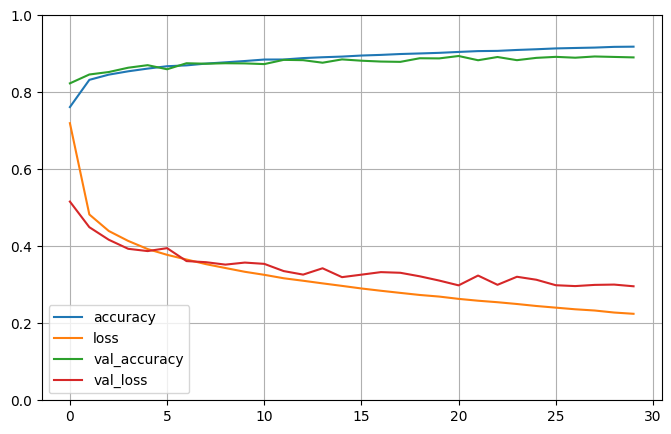

In [49]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

### Evaluating the Model on the Test Set

Once you are satisfied with your model's validation accuracy, you should evaluate it on the test set to estimate the **generalization error** before you deploy the model. This is done using the `evaluate()` method.

> **Important:** Resist the temptation to tweak hyperparameters based on the test set results, or your estimate of the generalization error will be too optimistic.

In [50]:
# Evaluate the model on the test set
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8495 - loss: 62.5746


[62.57455062866211, 0.8495000004768372]

## Using the Model to Make Predictions

Next, we can use the model’s `predict()` method to make predictions on new instances. Since we don’t have actual new instances, we will just use the first 3 instances of the test set:

### Understanding Probability Outputs
For each instance, the model estimates one probability per class (from class 0 to class 9). For example, if the first image has a high probability for class 9, the model "believes" it is an ankle boot.

### Identifying the Predicted Class
If you only care about the class with the highest estimated probability, you can use `np.argmax()` on the prediction results.

> **Note:** In older versions of Keras, `predict_classes()` was used, but it has been deprecated in favor of using `predict()` and manually taking the `argmax`.

In [57]:
x_new = x_test[:3]
y_prob = model.predict(x_new)
y_prob.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [58]:
import numpy as np

# Get the class with the highest probability
y_pred = np.argmax(y_proba, axis=-1)
y_pred

array([9, 2, 1])

In [59]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [61]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)